# Análise RFM - Visualizações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rfm = pd.read_csv('../data/processed/rfm.csv')

In [3]:
rfm.head()

,Customer ID,recencia,frequencia,monetario,R,F,M,RFM_Score,Segmento
0,12346,326,12,77556.46,2,5,5,255,Não Posso Perder
1,12347,2,8,4921.53,5,4,5,545,Campeões
2,12348,75,5,2019.40,3,4,4,344,Clientes Fiéis
3,12349,19,4,4428.69,5,3,5,535,Clientes Fiéis
4,12350,310,1,334.40,2,1,2,212,Perdidos


In [4]:
rfm.shape

(5878, 9)

Gráficos

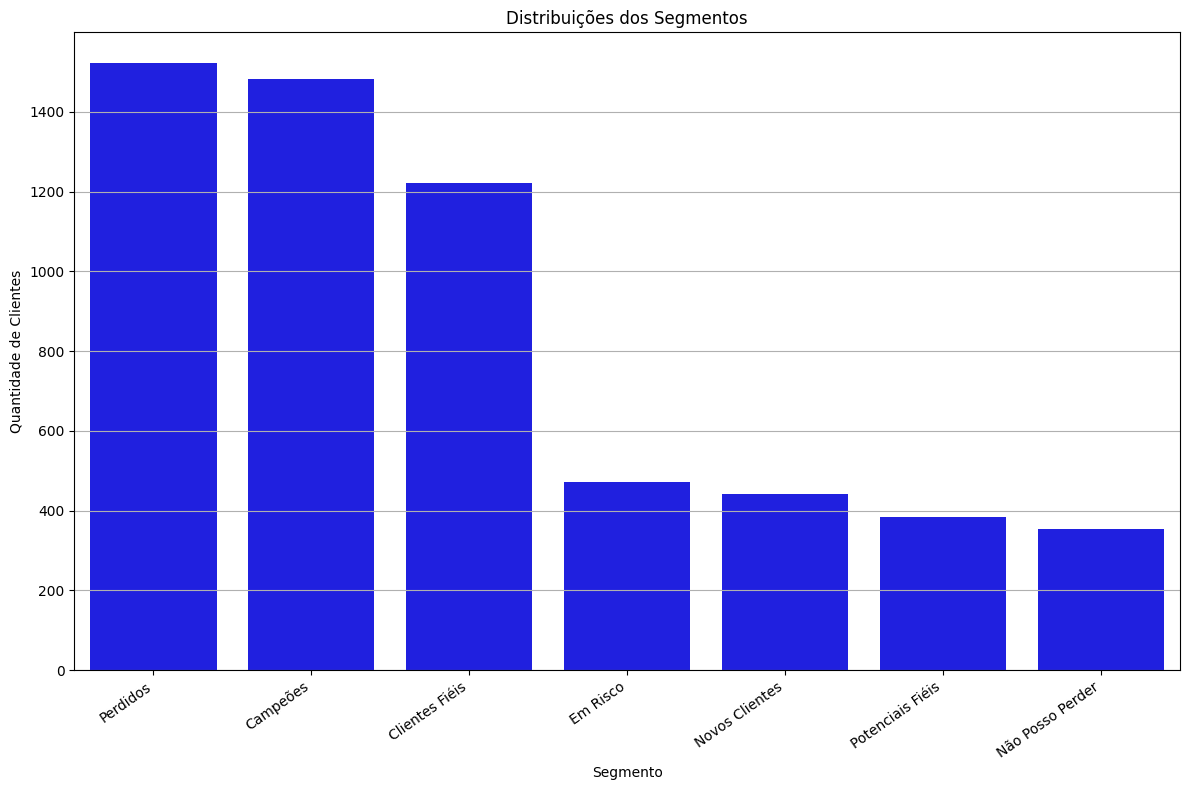

In [5]:
ordem = rfm['Segmento'].value_counts().index

plt.figure(figsize=(12, 8))
sns.countplot(data=rfm, x='Segmento', order=ordem, color='blue')
plt.title('Distribuições dos Segmentos')
plt.xlabel('Segmento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../reports/figures/segmentos.png', dpi=150)
plt.show()


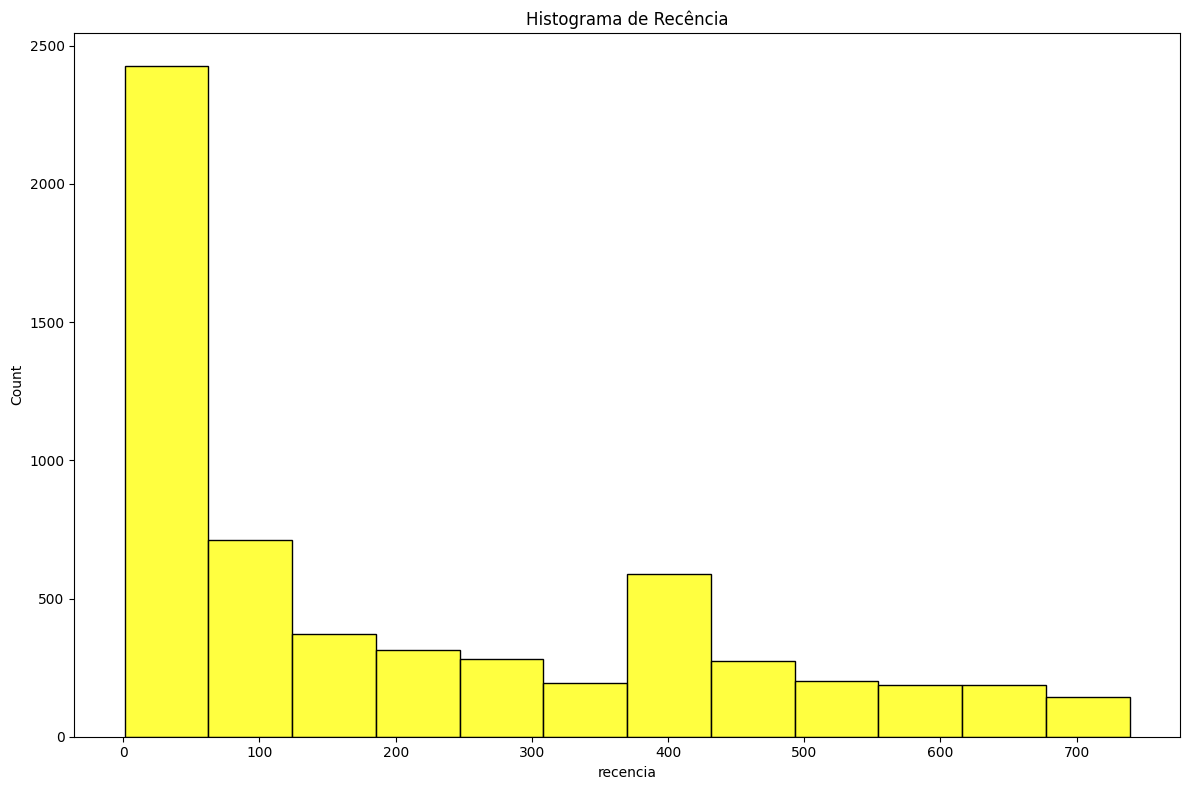

In [23]:
plt.figure(figsize=(12, 8))

sns.histplot(data=rfm, x='recencia', color='yellow', bins=12)
plt.title('Histograma de Recência')
plt.tight_layout()
plt.savefig('../reports/figures/histograma_recencia.png', dpi=150)
plt.show()

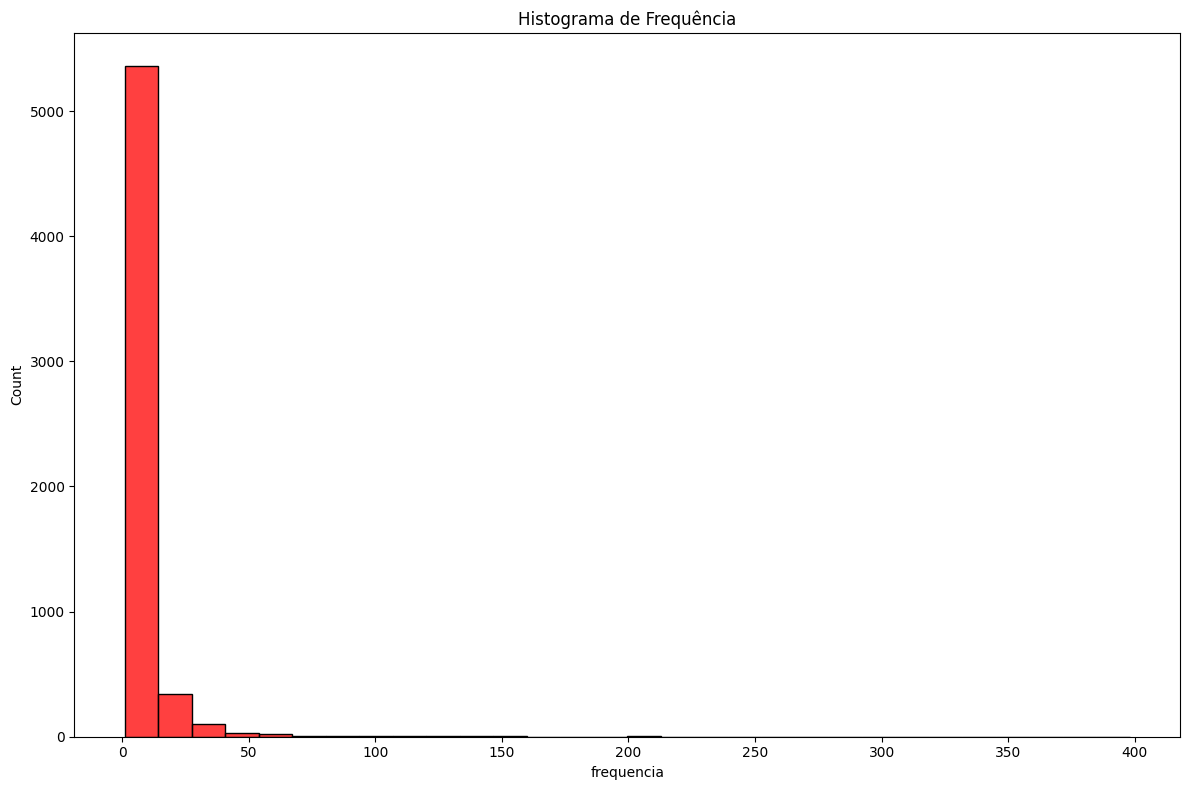

In [18]:
plt.figure(figsize=(12, 8))

sns.histplot(data=rfm, x='frequencia', color='red', bins=30)
plt.title('Histograma de Frequência')
plt.tight_layout()
plt.savefig('../reports/figures/histograma_frequencia.png', dpi=150)
plt.show()

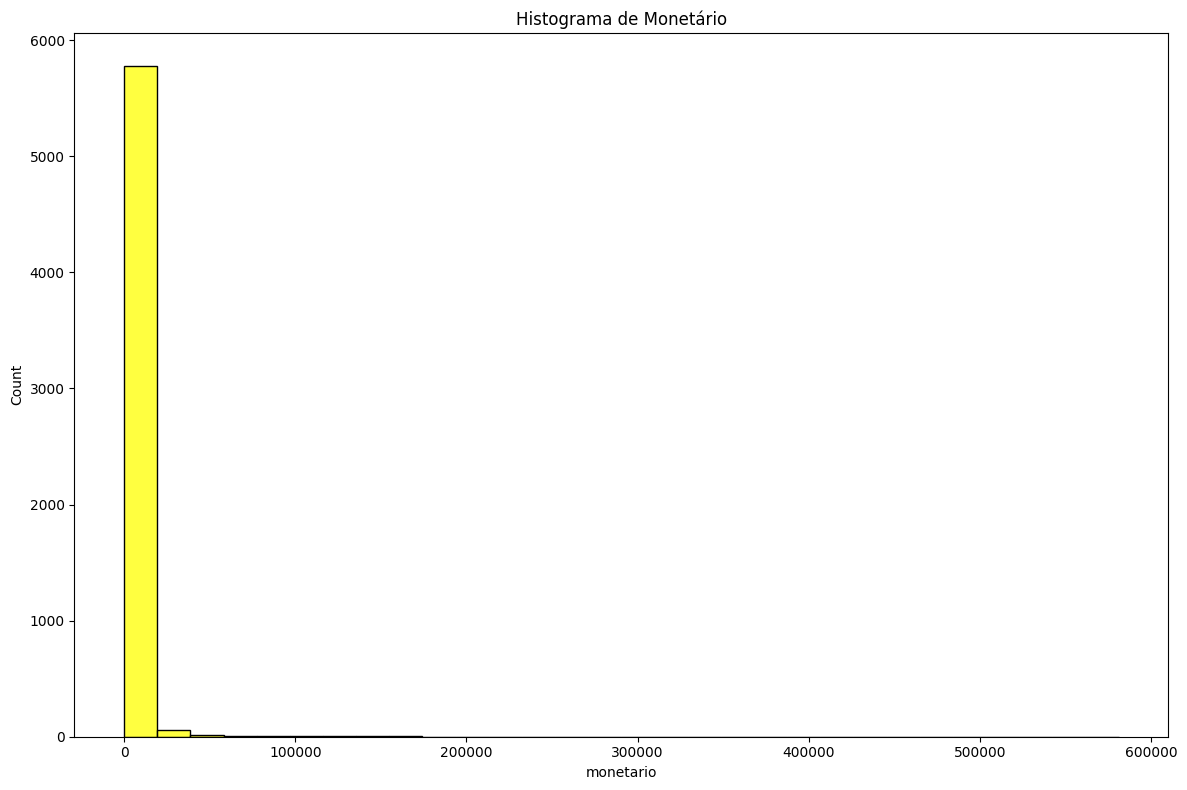

In [19]:
plt.figure(figsize=(12, 8))

sns.histplot(data=rfm, x='monetario', color='yellow', bins=30)
plt.title('Histograma de Monetário')
plt.tight_layout()
plt.savefig('../reports/figures/histograma_monetario.png', dpi=150)
plt.show()

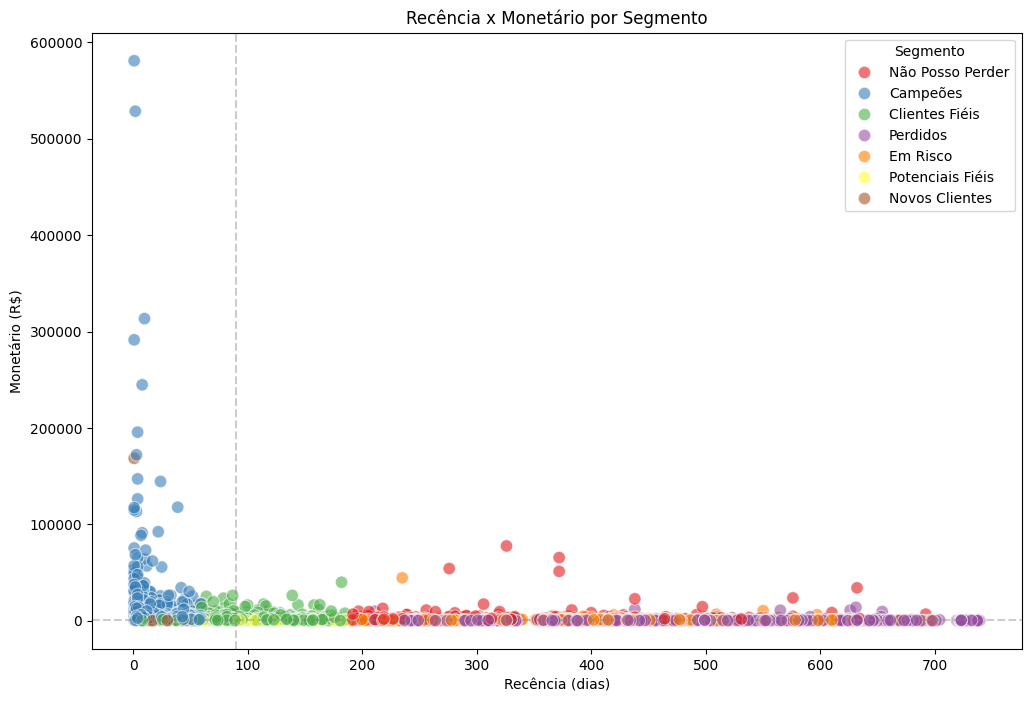

In [24]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=rfm,
    x='recencia',
    y='monetario',
    hue='Segmento',
    palette='Set1',
    alpha=0.6,
    s=80
)

plt.axvline(x=90, color='gray', linestyle='--', alpha=0.4)
plt.axhline(y=300, color='gray', linestyle='--', alpha=0.4)

plt.xlabel('Recência (dias)')
plt.ylabel('Monetário (R$)')
plt.title('Recência x Monetário por Segmento')
plt.legend(title='Segmento')
plt.savefig('../reports/figures/recencia_monetario_segmento.png', dpi=150)
plt.show()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_1120\3777605659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Segmento', y='monetario', order=ordem, palette='Set1')


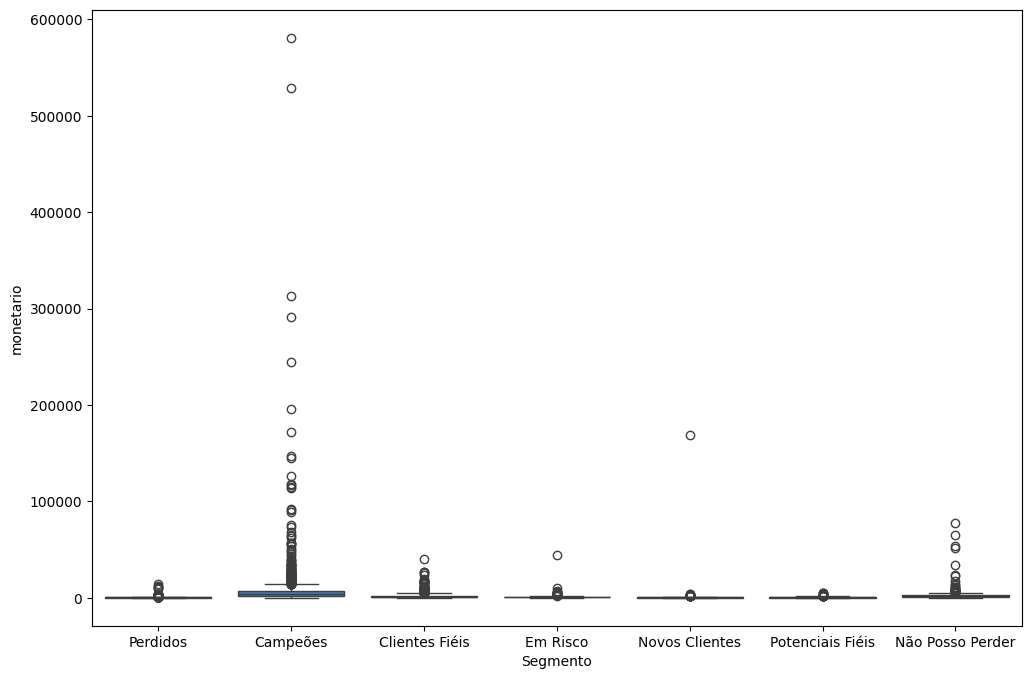

In [21]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=rfm, x='Segmento', y='monetario', order=ordem, palette='Set1')
plt.savefig('../reports/figures/boxplot_segmentos.png', dpi=150)
plt.show()

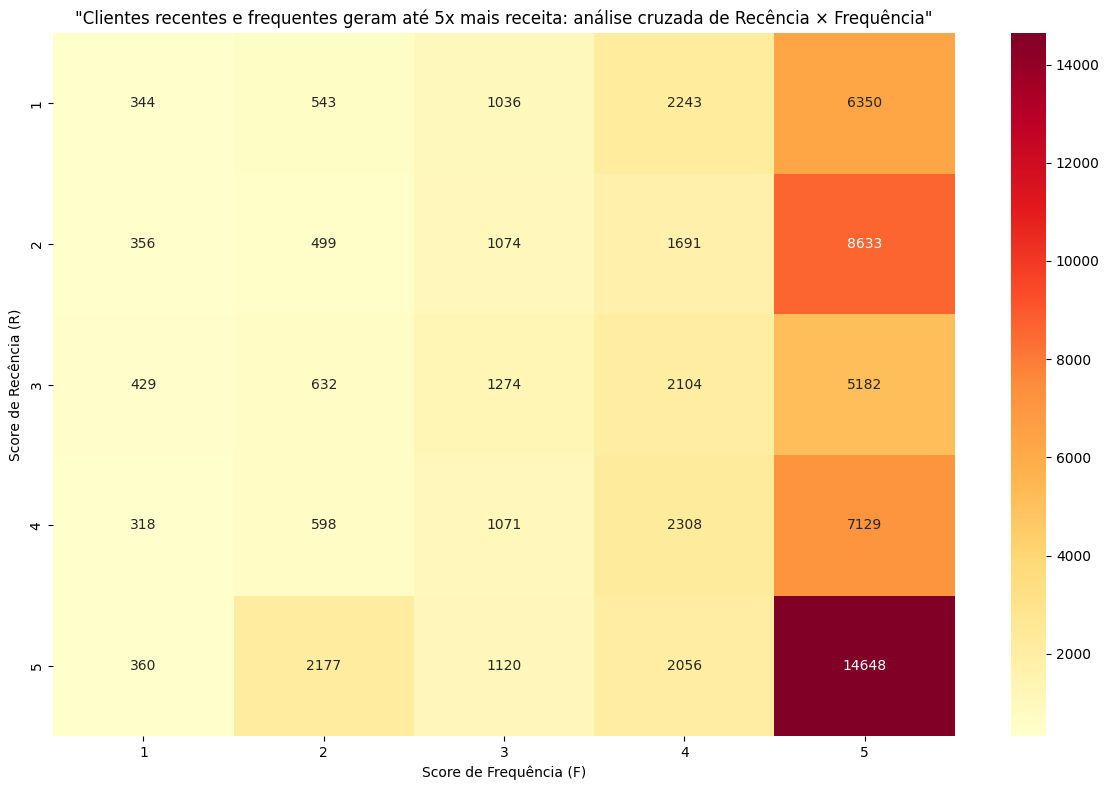

In [16]:
plt.figure(figsize=(12, 8))

heatmap_data = rfm.groupby(['R', 'F'])['monetario'].mean().unstack()

sns.heatmap(
    data=heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)
plt.title('"Clientes recentes e frequentes geram até 5x mais receita: análise cruzada de Recência × Frequência"')
plt.xlabel('Score de Frequência (F)')
plt.ylabel('Score de Recência (R)')
plt.tight_layout()
plt.savefig('../reports/figures/heatmap_rfm.png', dpi=150)
plt.show()

## Principais Insights

- Clientes Perdidos é o maior segmento — reativação deve ser prioridade
- Campeões e Fiéis formam o núcleo saudável da base e concentram o maior valor monetário
- A maioria dos clientes tem baixa frequência e baixo ticket — comportamento típico de e-commerce
- Frequência é o principal driver de receita: clientes com F=5 geram valor médio muito superior
- Segmentos Campeões e Não Posso Perder têm clientes outliers de alto valor — merecem atenção individualizada